### Лабораторная работа №7
#### «Корреляционный и  дисперсионный анализ данных»

В файле insurance.csv представлены данные о стоимости медицинской страховки в зависимости от комбинации различных факторов.   
Исследовались переменные:   
1. age: возраст (количественная)   
2. sex: пол (категориальная: male/female)   
3. bmi: индекс массы тела (количественная)   
4. children: количество детей/иждивенцев (дискретная количественная)   
5. smoker: курит ли (категориальная: yes/no)   
6. region: регион (категориальная: southwest/southeast/northwest/northeast)   
7. charges: стоимость страховки.

1. Установить три переменные, имеющие наибольшую корреляционную связь со стоимостью 
медицинской страховки (charges).   
Для количественных переменных сравнить значения различных коэффициентов корреляции.    
Проверить значимость коэффициентов корреляции.   
Построить корреляционную матрицу для всех количественных переменных.

In [5]:
# Номинальные — для классификации измеряемых признаков. Могут характеризоваться текстовым
# значением, но всегда можно сопоставить с числом (числовые метки). Примеры: пол, группа крови, место работы, любые признаки типа «да — нет». 
# Доступные операции: равны или нет.
# sex, smoker, region

# Порядковые (ординальные) — для сравнения признаков.
# Доступны операции сравнения. Примеры: данные типа «лучше - хуже», оценки, разряды, уровень образования и т. д.

# Количественные — все остальные. Они могут отличаться доступными арифметическими
# операциями, имеющими осмысленное значение. Например, дата (операции сравнения и вычитания), размер (все операции).
# age, bmi, children, charges

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Связь признаков с charges (по убыванию модуля):
 charges        1.000000
smoker_code    0.787251
age            0.299008
bmi            0.198341
children       0.067998
sex_code       0.057292
Name: charges, dtype: float64


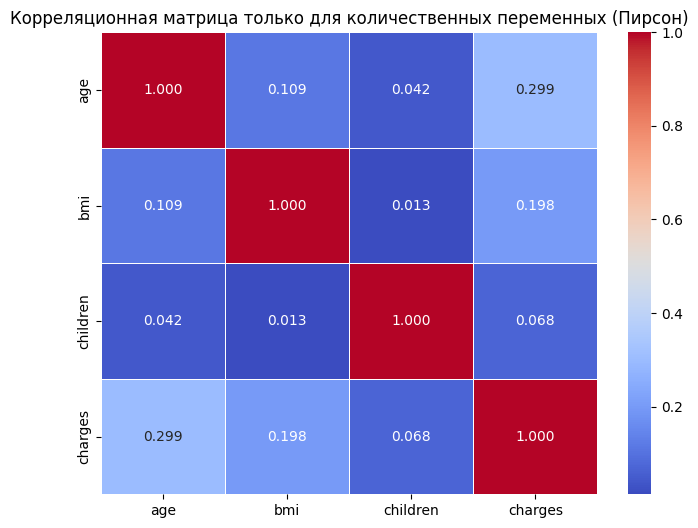


1) Анализ связи charges и age
1. Метод Пирсон: Коэффициент = 0.2990, p-value = 4.887e-29
   H0: Линейная связь между charges и age отсутствует (r = 0)
   Вывод: Так как p-value < 0.05, нулевая гипотеза H0 ОТВЕРГАЕТСЯ.
          Обнаруженная связь математически достоверна.
2. Метод Спирмен: Коэффициент = 0.5344, p-value = 1.131e-99
   H0: Ранговая связь между charges и age отсутствует (r_s = 0)
   Вывод: Так как p-value < 0.05, нулевая гипотеза H0 ОТВЕРГАЕТСЯ.
          Обнаруженная связь математически достоверна.
3. Метод Кендалл: Коэффициент = 0.4753, p-value = 2.589e-146
   H0: Связь по Кендаллу между charges и age отсутствует (t = 0)
   Вывод: Так как p-value < 0.05, нулевая гипотеза H0 ОТВЕРГАЕТСЯ.
          Обнаруженная связь математически достоверна.

2) Анализ связи charges и bmi
1. Метод Пирсон: Коэффициент = 0.1983, p-value = 2.459e-13
   H0: Линейная связь между charges и bmi отсутствует (r = 0)
   Вывод: Так как p-value < 0.05, нулевая гипотеза H0 ОТВЕРГАЕТСЯ.
          Обн

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("insurance.csv")
print(df.head())

df_new = df.copy()
df_new['sex_code'] = df_new['sex'].apply(lambda x: 1 if x == 'male' else 0) #перекодированный столбец пола
df_new['smoker_code'] = df_new['smoker'].apply(lambda x: 1 if x == 'yes' else 0) #перекодированный столбец курения

#считаем матрицу Пирсона для выбора топ-3
total_corr = df_new.drop(columns=['region', 'sex', 'smoker']).corr(method='pearson')['charges'].abs()
print("Связь признаков с charges (по убыванию модуля):\n", total_corr.sort_values(ascending=False))
#Корреляционная матрица только для количественных переменных
cols = ['age', 'bmi', 'children', 'charges']
corr_pearson = df[cols].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Корреляционная матрица только для количественных переменных (Пирсон)")
plt.show()

#Сравнение коэффициентов (Пирсон, Спирмен, Кендалл) и проверка значимости
# H0: коэффициент корреляции = 0 (связи нет)
# H1: коэффициент корреляции != 0 (связь есть)
# уровень значимости a = 0.05   
methods = ['Пирсон', 'Спирмен', 'Кендалл']
u=1
spearman_corr=[]
kendall=[]
for col in ['age', 'bmi', 'children']:
    print(f"\n{u}) Анализ связи charges и {col}")
    i=1
    for method in methods:
        if method == 'Пирсон':
            a = stats.pearsonr(df[col], df['charges'])
            r, p_val = a[0], a[1]
            h0_text = f"Линейная связь между charges и {col} отсутствует (r = 0)"
        elif method == 'Спирмен':
            a = stats.spearmanr(df[col], df['charges'])
            r, p_val = a[0], a[1]
            h0_text = f"Ранговая связь между charges и {col} отсутствует (r_s = 0)"
            spearman_corr.append((col, abs(r)))
        elif method == 'Кендалл':
            a = stats.kendalltau(df[col], df['charges'])
            r, p_val = a[0], a[1]
            h0_text = f"Связь по Кендаллу между charges и {col} отсутствует (t = 0)"
            kendall.append((col, abs(r)))
        print(f"{i}. Метод {method.capitalize()}: Коэффициент = {r:.4f}, p-value = {p_val:.3e}")
        print(f"   H0: {h0_text}")
        i+=1
        if p_val < 0.05:
            print(f"   Вывод: Так как p-value < 0.05, нулевая гипотеза H0 ОТВЕРГАЕТСЯ.")
            print(f"          Обнаруженная связь математически достоверна.")
        else:
            print(f"   Вывод: Так как p-value >= 0.05, нулевая гипотеза H0 ПРИНИМАЕТСЯ.")
            print(f"          Связь статистически НЕ значима (может быть случайной).")
    u+=1
res_smoker_s = stats.spearmanr(df_new['smoker_code'], df_new['charges']).correlation
res_sex_s = stats.spearmanr(df_new['sex_code'], df_new['charges']).correlation
spearman_corr.append(('sex_code', abs(res_sex_s)))
spearman_corr.append(('smoker_code', abs(res_smoker_s)))


In [7]:
# H0: распределение является нормальным
# H1: распределение не является нормальным
# Уровень значимости a = 0.05

normal = {}
kol = ['age', 'bmi', 'children', 'charges']
print("Проверка нормальности распределений:")
for var in kol:
    mu = np.mean(df_new[var])
    sigma = np.std(df_new[var], ddof=1)
    ks_stat, p_value = stats.kstest(df_new[var], 'norm', args=(mu, sigma))
    print(f"{var}:")
    print(f" D_n = {ks_stat:.4f}, p-value = {p_value:.6f}")
    if p_value >= 0.05:
        print(f" => распределение НОРМАЛЬНОЕ")
    else:
        print(f" => распределение НЕ НОРМАЛЬНОЕ")

print("Три переменные с наибольшей корреляцией с charges")
top3 = sorted(spearman_corr, key=lambda x: x[1], reverse=True)[:3]
for i, (var, corr) in enumerate(top3, 1):
    print(f"{i}. {var}: коэффициент = {corr:.4f}")


Проверка нормальности распределений:
age:
 D_n = 0.0789, p-value = 0.000000
 => распределение НЕ НОРМАЛЬНОЕ
bmi:
 D_n = 0.0261, p-value = 0.316280
 => распределение НОРМАЛЬНОЕ
children:
 D_n = 0.2471, p-value = 0.000000
 => распределение НЕ НОРМАЛЬНОЕ
charges:
 D_n = 0.1885, p-value = 0.000000
 => распределение НЕ НОРМАЛЬНОЕ
Три переменные с наибольшей корреляцией с charges
1. smoker_code: коэффициент = 0.6635
2. age: коэффициент = 0.5344
3. children: коэффициент = 0.1333


2. Установить наличие корреляционной связи между полом (sex) и курением (smoke).

In [8]:
#sex и smoke это два категориальных (качественных признака)
#Таблица сопряженности:
contingency_table = pd.crosstab(df['sex'], df['smoker'])
print("Таблица сопряженности:\n", contingency_table)

print("Проверка статистической значимости критерием Хи-квадрат:")
print(f"   H0: Пол и курение независимы друг от друга (связи между ними нет)")
print(f"   H1: Пол и курение взаимосвязаны (существует статистически значимая связь) \n")

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Критерий Хи-квадрат: {chi2:.4f}")
print(f"p-value: {p_val:.4f}\n")

if p_val < 0.05:
    print(f"Вывод: Так как p-value < 0.05, нулевая гипотеза H0 отвергается")
    print(f"   Взаимосвязь между полом и склонностью к курению достоверна")
else:
    print(f"Вывод: Так как p-value >= 0.05, нулевая гипотеза H0 принимается")
    print(f"   Статистически значимой связи между полом и курением нет")

Таблица сопряженности:
 smoker   no  yes
sex             
female  547  115
male    517  159
Проверка статистической значимости критерием Хи-квадрат:
   H0: Пол и курение независимы друг от друга (связи между ними нет)
   H1: Пол и курение взаимосвязаны (существует статистически значимая связь) 

Критерий Хи-квадрат: 7.3929
p-value: 0.0065

Вывод: Так как p-value < 0.05, нулевая гипотеза H0 отвергается
   Взаимосвязь между полом и склонностью к курению достоверна


## 3. На основе однофакторного дисперсионного анализа выяснить, влияют ли:
1) *фактор курения,*  
2) *индекс массы тела,*  
3) *возраст (разделить на 3 категории)*  
    на стоимость медицинской страховки?  
*Сделать визуализацию распределения данных по группам на основе boxplot.   
*Проверить выполнение требований для дынных, которые необходимы для проведения
классического дисперсионного анализа. Если требования не выполнены, все равно провести 
дисперсионный анализ.

### Алгоритм проведения однофакторного дисперсионного анализа
#### Проверка гипотезы о нормальном распределение исходных случайных величин Yi, i = 1...n Критерии Колмогорова и Хи-квадрат.

In [9]:
# Фактор курения
print("\n Фактор 1: курение (smoker)")

# Данные по группам 
group_yes = df[df["smoker"] == "yes"]["charges"]
group_no = df[df["smoker"] == "no"]["charges"]

#Тест Колмогорова-Смирнова
print("Проверка нормальности (тест Колмогорова-Смирнова):")
def check_norm(group, group_name): #функция для нормальности
    mu = np.mean(group)
    sigma = np.std(group, ddof=1)
    ks_stat, p_value = stats.kstest(group, 'norm', args=(mu, sigma))
    print(f"  Группа '{group_name}': D_n = {ks_stat:.4f}, p-value = {p_value:.4e}")
    if p_value >= 0.05:
        print(f"    {p_value:.6f} >= 0.05 => распределение НОРМАЛЬНОЕ")
    else:
        print(f"    {p_value:.6f} < 0.05 => распределение НЕ НОРМАЛЬНОЕ")
    return p_value

check_norm(group_yes, 'Курящие')
check_norm(group_no, 'Не курящие')


 Фактор 1: курение (smoker)
Проверка нормальности (тест Колмогорова-Смирнова):
  Группа 'Курящие': D_n = 0.1214, p-value = 5.6503e-04
    0.000565 < 0.05 => распределение НЕ НОРМАЛЬНОЕ
  Группа 'Не курящие': D_n = 0.1112, p-value = 6.3795e-12
    0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ


np.float64(6.379515833221225e-12)

## Тест Левена (Проверка равенства дисперсий двух или более групп)

**Зачем нужен этот тест?**  
Перед проведением дисперсионного анализа (ANOVA) важно убедиться, что разброс данных (дисперсия) внутри каждой группы примерно одинаков. Внутри каждой группы стоимость страховки колеблется из-за случайных факторов. Если условия для всех групп равны, то и этот случайный разброс должен быть одинаковым. Тест Левена как раз проверяет это равенство.

- **Нулевая гипотеза ($H_0$):** Дисперсии генеральных совокупностей во всех группах равны (можно делать ANOVA).  
    $$H_0: \sigma_1 = \sigma_2 = \dots = \sigma_k$$
- **Альтернативная гипотеза ($H_1$):** Дисперсии хотя бы в двух группах различаются.
- **Статистика теста:** основана на абсолютных отклонениях значений от групповых медиан (реже — средних или усечённых средних).

**Формула статистики Левена (на основе медиан):**

$$
W = \frac{(N - k)}{(k - 1)} \cdot \frac{\sum_{i=1}^{k} n_i (\bar{z}_{i\cdot} - \bar{z}_{\cdot\cdot})^2}{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (z_{ij} - \bar{z}_{i\cdot})^2}
$$

где:

- $z_{ij} = |x_{ij} - \text{медиана}_i|$
- $N$ — общий объём выборки
- $k$ — количество групп
- $n_i$ — размер i-й группы
- $\bar{z}_{i\cdot}$ — среднее $z$ в группе $i$
- $\bar{z}_{\cdot\cdot}$ — общее среднее $z$

**Результат:** p-value. Если p < выбранного уровня значимости (обычно 0.05), нулевая гипотеза отвергается => дисперсии значимо различаются.

---

## Пункты выполнения теста Левена

### 1. Подготовка данных
- Данные должны быть числовыми.
- Разбиты на две или более независимых группы (по одному категориальному признаку).
- Проверка на пропуски (рекомендуется удалить).   

(Берём числовую стоимость страховки и делим её на группы по нашему фактору (например: курящие и некурящие))
### 2. Выбор модификации теста
- **По медианам** (рекомендуется, устойчив к ненормальному распределению). Берём его.
- По средним (классическая версия, чувствительна к асимметрии).
- По усечённым средним (компромисс).

### 3. Расчёт центров групп
- Для медианного варианта: вычислить медиану в каждой группе.
- Для среднего: вычислить среднее арифметическое в каждой группе.

### 4. Вычисление абсолютных отклонений
Для каждого наблюдения в группе i:
$$
z_{ij} = |x_{ij} - \text{center}_i|
$$

- center это медиана или среднее

(Для каждого человека считаем, насколько стоимость его страховки ($x_{ij}$) отличается от медианы его группы. Минусы убираем (берем модуль))

### 5. Выполнение ANOVA на преобразованных данных z
- Проводим обычный дисперсионный анализ, но уже не для самой стоимости страховки, а для полученных отклонений $z$.
- Результат: значение F-статистики и p-value.

### 6. Принятие решения
*   **Если $p < 0.05$** -> Нулевая гипотеза отвергается. Разброс в группах слишком разный.
*   **Если $p \ge 0.05$** -> Отклонений нет. Дисперсии групп равны. Проводим **ANOVA**

In [10]:
print("\nПроверка однородности дисперсий (тест Левена):")
stat, p_value_levene = stats.levene(group_yes, group_no)
print(f"  Статистика Левена: L = {stat:.4f}, p-value = {p_value_levene:.4e}")

if p_value_levene >= 0.05:
    print(f"p-value = {p_value_levene:.4e} >= 0.05 => Дисперсии ОДНОРОДНЫ => ANOVA можно проводить")
else:
    print(f"p-value = {p_value_levene:.4e} < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => ANOVA проводить нельзя")


Проверка однородности дисперсий (тест Левена):
  Статистика Левена: L = 332.6135, p-value = 1.5593e-66
p-value = 1.5593e-66 < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => ANOVA проводить нельзя


#### ANOVA (analysis of variance)  
  
Цель: определить, объясняет ли исследуемый фактор различия в данных между группами. Для этого сравнивают две оценки дисперсии: межгрупповую (отражает разброс между группами, вызванный фактором) и внутригрупповую (отражает случайный разброс внутри групп). Если фактор действительно влияет, то межгрупповая дисперсия значимо превышает внутригрупповую.

Смысл: общая изменчивость данных складывается из двух частей: изменчивости из-за фактора (между группами) и случайной изменчивости (внутри групп). Их отношение показывает, насколько важен фактор.   

Если фактор действительно важен, то различия между группами (факторный разброс) будут намного сильнее, чем случайный разброс внутри них.

#### 3. Влияние фактора проверяется проверкой гипотезы о значимости статистического критерия

*   **Нулевая гипотеза ($H_0$):** Средние значения во всех группах равны. Фактор **не влияет** на результат. C уровнем значимости $\alpha$
    $$H_0: M[Y_1] = M[Y_2] = ... = M[Y_k]$$
*   **Альтернативная гипотеза ($H_1$):** Хотя бы в одной паре средние значения различаются. Фактор **влияет**.

Формулы:
1. **Групповое среднее** (среднее в конкретной группе i):
   $$\bar{y}_i = \frac{1}{n_i} \sum_{j=1}^{n_i} y_{ij}$$

Зачем нужно: чтобы охарактеризовать типичное значение в каждой группе и сравнивать группы между собой.

2. **Общее среднее** (среднее по всей таблице (по всем данным)):
   $$\bar{y} = \frac{1}{N} \sum_{i=1}^{k} \sum_{j=1}^{n_i} y_{ij}$$

Зачем нужно: служит точкой отсчёта для оценки отклонений групповых средних от общего уровня.

3. **Общая выборочная дисперсия** (полная изменчивость всех данных вместе):
   $$S_{total}^2 = \frac{1}{N-1} \sum_{i=1}^{k} \sum_{j=1}^{n_i} (y_{ij} - \bar{y})^2$$

Зачем нужна: показывает общий разброс всех наблюдений относительно общего среднего. В ANOVA эта дисперсия разлагается на сумму межгрупповой и внутригрупповой дисперсий.

4. **Факторная дисперсия** (разброс между группами, объясненный фактором):
   $$S_X^2 = \frac{n}{k-1} \sum_{i=1}^{k} (\bar{y}_i - \bar{y})^2$$

5. **Остаточная дисперсия** (случайный разброс внутри групп):
   $$S_O^2 = \frac{1}{k} \sum_{i=1}^{k} s_i^2$$

### Критерий Фишера ($F$-статистика)

Что такое F: это отношение межгрупповой дисперсии к внутригрупповой. По своей сути F показывает, во сколько раз разброс между группами превышает случайный разброс внутри групп. Чем больше F, тем сильнее влияние фактора:

$$F = \frac{S_X^2}{S_O^2}$$

где F-статистика имеет распределение Фишера с df1 = k-1 и df2 = k(n-1) степенями свободы.

Для проверки нам понадобятся **степени свободы**:
* Числителя: $df_1 = k - 1$ *(где $k$ — число групп)*
* Знаменателя: $df_2 = k \cdot (n - 1)$ *(где $n$ — размер группы)*

Критическое значение:
$$F_{крит} = F_{\alpha}^{-1}(df1,\; df2)$$

где F_{$\alpha$}^{-1} — это обратная функция распределения Фишера (квантиль), а $\alpha$ — уровень значимости.

В Python критическая точка распределения Фишера ($F_{\text{крит}}$) для уровня значимости $\alpha$ находится командой:  

F_крит = stats.f.ppf(1 - α, df1, df2)   
или же p_value = 1 - stats.f.cdf(F_stat, df1, df2)
### Правило принятия решения

*   **Если $F > F_{\text{крит}}$ (или $p\text{-value} < 0.05$)** -> Нулевая гипотеза $H_0$ отвергается. Фактор **оказывает значимое влияние** на стоимость страховки.
*   **Если $F \le F_{\text{крит}}$ (или $p\text{-value} \ge 0.05$)** -> Нет оснований отвергать $H_0$. Влияние фактора **не доказано**, разница между группами случайна.(не влиет)


In [11]:
#Расчёт ANOVA

k = 2 # количество групп (курит/не курит)
n_yes = len(group_yes) #размер каждой группы
n_no = len(group_no)
N = n_yes + n_no  # общий объем выборки

# 1. Групповое среднее
y_bar_yes = np.mean(group_yes) # в группе "курит"
y_bar_no = np.mean(group_no) # в группе "не курит"

# 2. Общее среднее
y_bar = (y_bar_yes * len(group_yes) + y_bar_no * len(group_no)) / (len(group_yes) + len(group_no)) 
# y_bar = df["charges"].mean()

# 3. Внутригрупповые дисперсии
s2_yes = np.var(group_yes, ddof=1) # дисперсия внутри группы "курит"
s2_no = np.var(group_no, ddof=1) # дисперсия внутри группы "не курит"

# степени свободы
df1 = k - 1 # степени свободы числителя
df2 = N-k # степени свободы знаменателя

# 4. Межгрупповая дисперсия (с учетом объемов каждой группы)
sum_sq = n_yes * (y_bar_yes - y_bar)**2 + n_no * (y_bar_no - y_bar)**2 # сумма квадратов отклонений
Sx2 = sum_sq / df1

# 5. внутригрупповая дисперсия (остаточная)
sum_2 = (n_yes - 1) * s2_yes + (n_no - 1) * s2_no
So2 = sum_2 / df2

# 6. Статистика Фишера
F_stat = Sx2 / So2

alpha = 0.05 # уровень значимости
F_crit = stats.f.ppf(1 - alpha, df1, df2) # критическое значение

print(f"\nГруппа 'курит': n={n_yes}, среднее={y_bar_yes:.2f}, дисперсия={s2_yes:.2f}")
print(f"Группа 'не курит': n={n_no}, среднее={y_bar_no:.2f}, дисперсия={s2_no:.2f}")
print(f"Общее среднее: {y_bar:.2f}")
print(f"\nS_X^2 = {Sx2:.2f} (межгрупповая дисперсия)")
print(f"S_O^2 = {So2:.2f} (внутригрупповая дисперсия)")
print(f"F = {F_stat:.4f}")
print(f"F_крит = {F_crit:.4f}")

print("\nПроверка гипотезы (влияет ли фактор курения на стоимость страховки):")
print("  через критическое значение и наблюдаемое:")
if F_stat > F_crit:
    print(f"    {F_stat:.4f} > {F_crit:.4f} => H0 отвергается. Курение ВЛИЯЕТ на стоимость страховки.")
else:
    print(f"    {F_stat:.4f} <= {F_crit:.4f} => H0 принимается. Курение НЕ влияет на стоимость страховки.")



Группа 'курит': n=274, среднее=32050.23, дисперсия=133207311.21
Группа 'не курит': n=1064, среднее=8434.27, дисперсия=35925420.50
Общее среднее: 13270.42

S_X^2 = 121519903621.67 (межгрупповая дисперсия)
S_O^2 = 55804130.20 (внутригрупповая дисперсия)
F = 2177.6149
F_крит = 3.8484

Проверка гипотезы (влияет ли фактор курения на стоимость страховки):
  через критическое значение и наблюдаемое:
    2177.6149 > 3.8484 => H0 отвергается. Курение ВЛИЯЕТ на стоимость страховки.


In [12]:
# 2) Фактор индекса массы тела (bmi)
print("\nФактор 2: индекса массы тела (bmi)")

df['bmi_group'] = df['bmi'].apply(lambda x: 'Низкий' if x < 18.5 else 'Средний' if x < 25 else 'Высокий')
# Данные по группам
group_low = df[df['bmi_group'] == 'Низкий']['charges']
group_mid = df[df['bmi_group'] == 'Средний']['charges']
group_high = df[df['bmi_group'] == 'Высокий']['charges']

print("Проверка нормальности (тест Колмогорова-Смирнова):")
check_norm(group_low, 'Низкий')
check_norm(group_mid, 'Средний')
check_norm(group_high, 'Высокий')

print("\nПроверка однородности дисперсий (тест Левена):")
stat, p_value_levene = stats.levene(group_low, group_mid, group_high)
print(f"  Статистика Левена: L = {stat:.4f}, p-value = {p_value_levene:.6f}")

if p_value_levene >= 0.05:
    print(f"  {p_value_levene:.6f} >= 0.05 => Дисперсии ОДНОРОДНЫ => ANOVA можно проводить")
else:
    print(f"  {p_value_levene:.6f} < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => ANOVA проводить нельзя")

# РАСЧЕТ ANOVA
k = 3  # количество групп (Низкий/Средний/Высокий)
n_low = len(group_low) #размер каждой группы
n_mid = len(group_mid)
n_high = len(group_high)
N = n_high + n_low + n_mid  # общий объем выборки

# 1. Групповое среднее
y_bar_low = np.mean(group_low)  # среднее в группе "Низкий"
y_bar_mid = np.mean(group_mid)  # среднее в группе "Средний"
y_bar_high = np.mean(group_high)  # среднее в группе "Высокий"

# 2. Общее среднее
y_bar = (y_bar_low * len(group_low) + y_bar_mid * len(group_mid) + y_bar_high * len(group_high)) / N  

# 3. Внутригрупповые дисперсии
s2_low = np.var(group_low, ddof=1)  # дисперсия внутри группы "Низкий"
s2_mid = np.var(group_mid, ddof=1)  # дисперсия внутри группы "Средний"
s2_high = np.var(group_high, ddof=1)  # дисперсия внутри группы "Высокий"

# степени свободы
df1 = k - 1 # степени свободы числителя
df2 = N-k # степени свободы знаменателя

# 4. Межгрупповая дисперсия (факторная)
sum_sq = n_low * (y_bar_low - y_bar)**2 + n_mid * (y_bar_mid - y_bar)**2 + n_high * (y_bar_high - y_bar)**2 # сумма квадратов отклонений
Sx2 = sum_sq / df1

# 5. внутригрупповая дисперсия (остаточная)
sum_2 = (n_low - 1) * s2_low + (n_mid - 1) * s2_mid + (n_high - 1) * s2_high
So2 = sum_2 / df2

# 6. Статистика Фишера
F_stat = Sx2 / So2 

alpha = 0.05
F_crit = stats.f.ppf(1 - alpha, df1, df2)
print(f"\nГруппа 'Низкий': n={n_low}, среднее={y_bar_low:.2f}, дисперсия={s2_low:.2f}")
print(f"Группа 'Средний': n={n_mid}, среднее={y_bar_mid:.2f}, дисперсия={s2_mid:.2f}")
print(f"Группа 'Высокий': n={n_high}, среднее={y_bar_high:.2f}, дисперсия={s2_high:.2f}")
print(f"Общее среднее: {y_bar:.2f}")
print(f"\nS_X^2 = {Sx2:.2f} (межгрупповая дисперсия)")
print(f"S_O^2 = {So2:.2f} (внутригрупповая дисперсия)")
print(f"F = {F_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"F_крит = {F_crit:.4f}")

print("\nПроверка гипотезы (влияет ли индекс массы тела на стоимость страховки)")
print("  через критическое значение и наблюдаемое F_набл:")
if F_stat > F_crit:
    print(f"    {F_stat:.4f} > {F_crit:.4f} => H0 отвергается. Индекс массы тела ВЛИЯЕТ на стоимость страховки.")
else:
    print(f"    {F_stat:.4f} <= {F_crit:.4f} => H0 принимается. Индекс массы тела НЕ влияет на стоимость страховки.")


Фактор 2: индекса массы тела (bmi)
Проверка нормальности (тест Колмогорова-Смирнова):
  Группа 'Низкий': D_n = 0.1749, p-value = 5.1719e-01
    0.517186 >= 0.05 => распределение НОРМАЛЬНОЕ
  Группа 'Средний': D_n = 0.1107, p-value = 7.4438e-03
    0.007444 < 0.05 => распределение НЕ НОРМАЛЬНОЕ
  Группа 'Высокий': D_n = 0.2072, p-value = 1.2522e-41
    0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ

Проверка однородности дисперсий (тест Левена):
  Статистика Левена: L = 8.9135, p-value = 0.000143
  0.000143 < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => ANOVA проводить нельзя

Группа 'Низкий': n=20, среднее=8852.20, дисперсия=59830818.49
Группа 'Средний': n=225, среднее=10409.34, дисперсия=56333750.86
Группа 'Высокий': n=1093, среднее=13940.24, дисперсия=164465273.27
Общее среднее: 13270.42

S_X^2 = 1361298708.31 (межгрупповая дисперсия)
S_O^2 = 144832677.27 (внутригрупповая дисперсия)
F = 9.3991
p-value = 0.000000
F_крит = 3.0025

Проверка гипотезы (влияет ли индекс массы тела на стоимость страх

In [13]:
# 3) Фактор возраста (age)
print("\nФактор 3: возраст (age)")

df['age_group'] = df['age'].apply(lambda x: 'Молодой' if x < 35 else 'Средний' if x < 55 else 'Пожилой')

# Данные по группам
group_young = df[df['age_group'] == 'Молодой']['charges']
group_middle = df[df['age_group'] == 'Средний']['charges']
group_old = df[df['age_group'] == 'Пожилой']['charges']

print("Проверка нормальности (тест Колмогорова-Смирнова):")
check_norm(group_young, 'Молодой')
check_norm(group_middle, 'Средний')
check_norm(group_old, 'Пожилой')

print("\nПроверка однородности дисперсий (тест Левена):")
stat, p_value_levene = stats.levene(group_young, group_middle, group_old)
print(f"  Статистика Левена: L = {stat:.4f}, p-value = {p_value_levene:.6f}")

if p_value_levene >= 0.05:
    print(f"  {p_value_levene:.6f} >= 0.05 => Дисперсии ОДНОРОДНЫ => ANOVA можно проводить")
else:
    print(f"  {p_value_levene:.6f} < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => ANOVA проводить нельзя")


# РАСЧЕТ ANOVA
k = 3  # количество групп (Молодой/Средний/Пожилой)
n_young = len(group_young) #размер каждой группы
n_middle = len(group_middle)
n_old = len(group_old)
N = n_young + n_middle + n_old  # общий объем выборки

# 1. Групповое среднее
y_bar_young = np.mean(group_young)  # среднее в группе "Молодой"
y_bar_middle = np.mean(group_middle)  # среднее в группе "Средний"
y_bar_old = np.mean(group_old)  # среднее в группе "Пожилой"

# 2. Общее среднее
y_bar = (y_bar_young * n_young + y_bar_middle * n_middle + y_bar_old * n_old) / N  

# 3. Внутригрупповые дисперсии
s2_young = np.var(group_young, ddof=1)  # дисперсия внутри группы "Молодой"
s2_middle = np.var(group_middle, ddof=1)  # дисперсия внутри группы "Средний"
s2_old = np.var(group_old, ddof=1)  # дисперсия внутри группы "Пожилой"

# степени свободы
df1 = k - 1 # степени свободы числителя
df2 = N-k # степени свободы знаменателя

# 4. Межгрупповая дисперсия (факторная)
sum_sq = n_young * (y_bar_young - y_bar)**2 + n_middle * (y_bar_middle - y_bar)**2 + n_old * (y_bar_old - y_bar)**2 # сумма квадратов отклонений
Sx2 = sum_sq / df1

# 5. внутригрупповая дисперсия (остаточная)
sum_2 = (n_young - 1) * s2_young + (n_middle - 1) * s2_middle + (n_old - 1) * s2_old
So2 = sum_2 / df2

# 6. Статистика Фишера
F_stat = Sx2 / So2 

alpha = 0.05
F_crit = stats.f.ppf(1 - alpha, df1, df2)

print(f"\nГруппа 'Молодой': n={n_young}, среднее={y_bar_young:.2f}, дисперсия={s2_young:.2f}")
print(f"Группа 'Средний': n={n_middle}, среднее={y_bar_middle:.2f}, дисперсия={s2_middle:.2f}")
print(f"Группа 'Пожилой': n={n_old}, среднее={y_bar_old:.2f}, дисперсия={s2_old:.2f}")
print(f"Общее среднее: {y_bar:.2f}")
print(f"\nS_X^2 = {Sx2:.2f} (межгрупповая дисперсия)")
print(f"S_O^2 = {So2:.2f} (внутригрупповая дисперсия)")
print(f"F = {F_stat:.4f}")
print(f"F_крит = {F_crit:.4f}")

print("\nПроверка гипотезы (влияет ли возраст на стоимость страховки)")
print("  через критическое значение и наблюдаемое F_набл:")
if F_stat > F_crit:
    print(f"    {F_stat:.4f} > {F_crit:.4f} => H0 отвергается. Возраст ВЛИЯЕТ на стоимость страховки.")
else:
    print(f"    {F_stat:.4f} <= {F_crit:.4f} => H0 принимается. Возраст НЕ влияет на стоимость страховки.")




Фактор 3: возраст (age)
Проверка нормальности (тест Колмогорова-Смирнова):
  Группа 'Молодой': D_n = 0.3183, p-value = 5.8035e-50
    0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ
  Группа 'Средний': D_n = 0.3043, p-value = 1.9632e-45
    0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ
  Группа 'Пожилой': D_n = 0.3452, p-value = 2.9344e-26
    0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ

Проверка однородности дисперсий (тест Левена):
  Статистика Левена: L = 0.4521, p-value = 0.636365
  0.636365 >= 0.05 => Дисперсии ОДНОРОДНЫ => ANOVA можно проводить

Группа 'Молодой': n=549, среднее=9673.32, дисперсия=135075671.32
Группа 'Средний': n=547, среднее=14561.17, дисперсия=139789259.19
Группа 'Пожилой': n=242, среднее=18513.28, дисперсия=128883464.59
Общее среднее: 13270.42

S_X^2 = 7333451603.19 (межгрупповая дисперсия)
S_O^2 = 135885631.73 (внутригрупповая дисперсия)
F = 53.9678
F_крит = 3.0025

Проверка гипотезы (влияет ли возраст на стоимость страховки)
  через критическое значение и

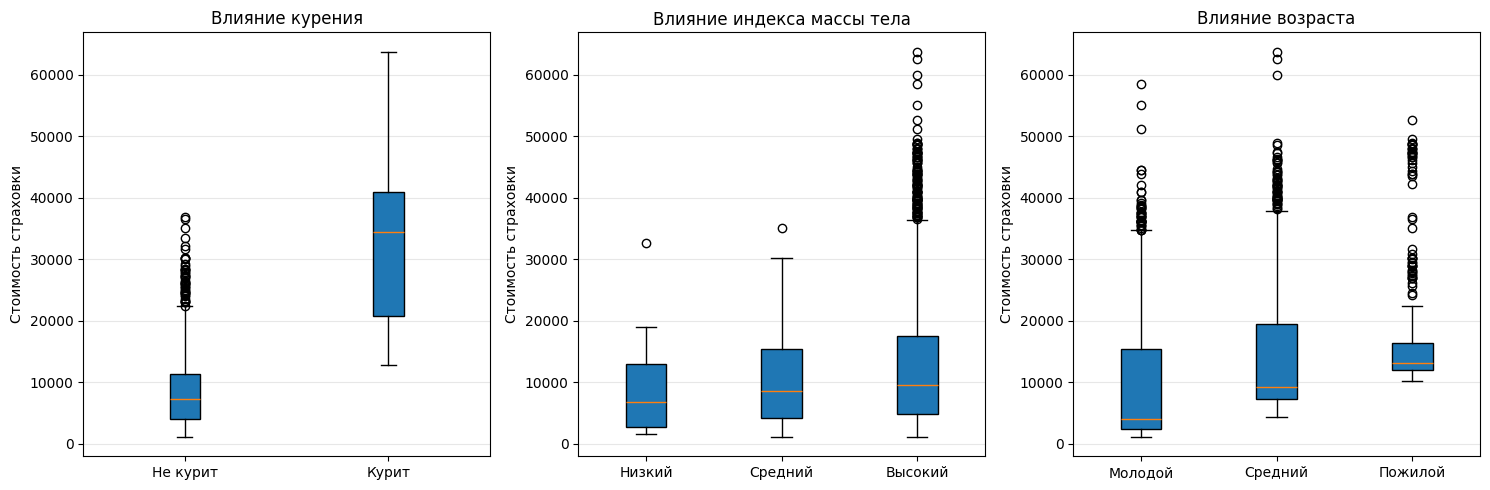

In [14]:
# Визуализация (boxplot)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: курение
ax1 = axes[0]
smoker_data = [group_no, group_yes]
ax1.boxplot(smoker_data, tick_labels=['Не курит', 'Курит'], patch_artist=True)
ax1.set_ylabel('Стоимость страховки')
ax1.set_title('Влияние курения')
ax1.grid(axis='y', alpha=0.3)

# График 2: BMI
ax2 = axes[1]
bmi_labels = ['Низкий', 'Средний', 'Высокий']
bmi_data = [df[df['bmi_group'] == g]['charges'] for g in bmi_labels]
ax2.boxplot(bmi_data, tick_labels=bmi_labels, patch_artist=True)
ax2.set_ylabel('Стоимость страховки')
ax2.set_title('Влияние индекса массы тела')
ax2.grid(axis='y', alpha=0.3)

# График 3: возраст
ax3 = axes[2]
age_labels = ['Молодой', 'Средний', 'Пожилой'] 
age_data = [df[df['age_group'] == g]['charges'] for g in age_labels]
ax3.boxplot(age_data, tick_labels=age_labels, patch_artist=True)
ax3.set_ylabel('Стоимость страховки')
ax3.set_title('Влияние возраста')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Передаем стоимость страховки и ваши три группы возраста
tukey_result = pairwise_tukeyhsd(endog=df['charges'], 
                                 groups=df['age_group'], 
                                 alpha=0.05)

print(tukey_result)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1  group2  meandiff  p-adj   lower     upper    reject
------------------------------------------------------------
Молодой Пожилой  8839.9593   0.0 6729.5394 10950.3792   True
Молодой Средний  4887.8552   0.0 3235.5133  6540.1972   True
Пожилой Средний -3952.1041   0.0 -6063.704 -1840.5042   True
------------------------------------------------------------


## 4. На основе двухфакторного дисперсионного анализа выяснить, влияет ли эффект курения 
на стоимость медицинской страховки по-разному для мужчин и женщин?

### Двухфакторный дисперсионный анализ (Two-Way ANOVA)

**Цель:** оценить влияние двух независимых качественных факторов ($A$ и $B$) на одну зависимую числовую переменную (стоимость страховки), включая оценку эффекта их взаимодействия между собой.

---

### Отличия от однофакторного ANOVA


| Характеристика | Однофакторный ANOVA | Двухфакторный ANOVA |
| :--- | :--- | :--- |
| **Количество факторов** | 1 | 2 ($A$ и $B$) |
| **Основной эффект** | $\sigma^2_A$ | $\sigma^2_A$, $\sigma^2_B$ |
| **Взаимодействие** | Нет | $\sigma^2_{AB}$ (ключевое отличие) |
| **Математическая модель** | $y = \mu + \alpha_i + \varepsilon$ | $y = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon$ |
| **Число $F$-критериев** | 1 | 3 (для фактора $A$, для $B$ и для взаимодействия $AB$) |

Эффект взаимодействия ($AB$) отвечает на главный вопрос исследования: «Зависит ли сила или направление эффекта фактора $A$ от того, на каком уровне находится фактор $B$?»

---

### Требования к входным данным

1. Независимость наблюдений (внутри групп и между группами)

2. Нормальное распределение остатков ε ~ N(0, σ^2) — проверяются на нормальность не исходные группы, а остатки единой построенной модели (тест Шапиро-Уилка, Q-Q plot).

3. Гомогенность дисперсий по всем ячейкам (σ^2_1 = σ^2_2 = ...): дисперсии стоимости во всех перекрестных группах (курящие мужчины, некурящие мужчины, курящие женщины, некурящие женщины) должны быть примерно равны. Проверяется тестом Левена.

4. Сбалансированность (желательна): одинаковое число наблюдений в каждой из AB групп

Возможности метода:

- Оценить раздельное влияние двух факторов (уменьшает необъяснённую дисперсию по сравнению с однофакторной модельмой) (Позволяет оценить чистое влияние курения отдельно и пола отдельно.)

- Обнаружить взаимодействие факторов: например, увеличивает ли курение стоимость страховки одинаково для всех, или оно бьет по карману мужчин сильнее, чем женщин (и наоборот)

- Сравнить средние внутри ячеек (тест Тьюки)




**ТЕСТ ШАПИРО-УИЛКА**

НАЗНАЧЕНИЕ: проверка выборки на принадлежность к нормальному распределению.

ЧТО ТАКОЕ ОСТАТОК:

Остаток — это разница между фактическим значением и предсказанным (средним по группе) значением.

В контексте ANOVA:
Остаток = y_ijk - y_bar_ij

где:
- y_ijk — фактическое значение наблюдения
- y_bar_ij — среднее значение в ячейке (группе) (i,j)

Смысл: остатки показывают, какая часть изменчивости НЕ объяснена (случайная ошибка).

Проверка нормальности остатков — это проверка того, что случайные ошибки распределены нормально.

НУЛЕВАЯ ГИПОТЕЗА (H0): распределение остатков НЕ ОТЛИЧАЕТСЯ от нормального (остатки распределены нормально)

АЛЬТЕРНАТИВНАЯ ГИПОТЕЗА (H1): распределение остатков ОТЛИЧАЕТСЯ от нормального (остатки НЕ нормальны)

ОГРАНИЧЕНИЯ: тест работает для выборок размером от 3 до 5000 наблюдений.

ФОРМУЛА СТАТИСТИКИ:

$$
W = \frac{(\sum_{i=1}^{n} a_i x_{(i)})^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

где:
- x_{(i)} — упорядоченные по возрастанию выборочные значения (i-я порядковая статистика)
- a_i — коэффициенты, зависящие от объёма выборки и математического ожидания порядковых статистик
- n — объём выборки

РЕШЕНИЕ:

Если p-value >= alpha (обычно 0.05) => H0 НЕ ОТВЕРГАЕТСЯ => остатки распределены НОРМАЛЬНО => условие выполнено.

Если p-value < alpha => H0 ОТВЕРГАЕТСЯ => остатки распределены НЕ НОРМАЛЬНО => условие нарушено.


In [16]:
# Цель: выяснить, влияет ли эффект курения на стоимость страховки по-разному для мужчин и женщин?
# Фактор A: курение (smoker) - 2 уровня (yes/no)
# Фактор B: пол (sex) - 2 уровня (male/female)
# Зависимая переменная: charges (стоимость страховки)

# 1.1. Независимость наблюдений
# данные взяты из разных страховых случаев, каждый человек уникален
# Результат: условие выполнено

# 1.2. Нормальное распределение остатков (тест Шапиро-Уилка)
# Остаток = y_ijk - y_bar_ij (отклонение наблюдения от среднего в своей ячейке)
# Смысл: остатки показывают, какая часть изменчивости не объяснена (случайная ошибка)

print("\n1.2. Нормальное распределение остатков (тест Шапиро-Уилка):")

# Гипотезы:
# H0: остатки распределены нормально (условие выполнено)
# H1: остатки распределены не нормально (условие нарушено)

def check_normality_shapiro(data, name):
    if len(data) >= 3 and len(data) <= 5000:
        stat, p_value = stats.shapiro(data)
        print(f"   {name}: W = {stat:.4f}, p-value = {p_value:.4e}")
        if p_value >= 0.05:
            print(f"      {p_value:.4e} >= 0.05 => H0 не отвергается => распределение НОРМАЛЬНОЕ")
            return True
        else:
            print(f"      {p_value:.4e} < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ")
            return False
    else:
        print(f"   {name}: размер выборки {len(data)} не подходит для теста Шапиро-Уилка")
        return None

# Создаем пустой список для всех остатков
residuals_all = []

for s in ['yes', 'no']:
    for g in ['male', 'female']:
        
        # Отбираем данные для текущей группыЫ (smoker=s, sex=g)
        group_data = df[(df['smoker'] == s) & (df['sex'] == g)]['charges']
        
        # Вычисляем среднее по группе
        group_mean = group_data.mean()
        
        # Вычисляем остатки = фактические значения - среднее по группе
        residuals = group_data - group_mean
        
        # Добавляем остатки в общий список
        for r in residuals:
            residuals_all.append(r)
        
        # Проверяем нормальность остатков в текущей группе
        check_normality_shapiro(residuals, f"Пол: {g} / Курение: {s}")

# Проверяем нормальность всех остатков вместе (дополнительно)
print("\n   Общая проверка остатков:")
check_normality_shapiro(np.array(residuals_all), "Все остатки")



1.2. Нормальное распределение остатков (тест Шапиро-Уилка):
   Пол: male / Курение: yes: W = 0.9381, p-value = 2.0797e-06
      2.0797e-06 < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ
   Пол: female / Курение: yes: W = 0.9311, p-value = 1.6863e-05
      1.6863e-05 < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ
   Пол: male / Курение: no: W = 0.8737, p-value = 4.5926e-20
      4.5926e-20 < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ
   Пол: female / Курение: no: W = 0.8662, p-value = 3.2055e-21
      3.2055e-21 < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ

   Общая проверка остатков:
   Все остатки: W = 0.9584, p-value = 4.3863e-19
      4.3863e-19 < 0.05 => H0 отвергается => распределение НЕ НОРМАЛЬНОЕ


False

In [17]:
# 1.3. Гомогенность дисперсий (тест Левена)
print("\n1.3. Гомогенность дисперсий (тест Левена):")

# Шаг 1: Создаем пустой список для групп
groups = []

# Шаг 2: Проходим по всем комбинациям пола и курения
for s in ['yes', 'no']:
    for g in ['male', 'female']:
        # Шаг 3: Отбираем данные для каждой группы
        group_data = df[(df['smoker'] == s) & (df['sex'] == g)]['charges']
        # Шаг 4: Добавляем группу в список
        groups.append(group_data)
        # Шаг 5: Выводим дисперсию каждой группы
        print(f"   {g}/{s}: дисперсия = {group_data.var(ddof=1):.2f}")

# Шаг 6: Применяем тест Левена
stat_levene, p_levene = stats.levene(groups[0], groups[1], groups[2], groups[3])

# Шаг 7: Выводим результат в экспоненциальном формате
print(f"\nСтатистика Левена: L = {stat_levene:.4f}, p-value = {p_levene:.4e}")

# Шаг 8: Делаем вывод
if p_levene >= 0.05:
    print(f"   {p_levene:.4e} >= 0.05 => Дисперсии ОДНОРОДНЫ => условие выполнено")
else:
    print(f"   {p_levene:.4e} < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => условие нарушено")



1.3. Гомогенность дисперсий (тест Левена):
   male/yes: дисперсия = 125499834.44
   female/yes: дисперсия = 141789422.66
   male/no: дисперсия = 34905751.83
   female/no: дисперсия = 36733005.36

Статистика Левена: L = 99.6357, p-value = 3.3973e-58
   3.3973e-58 < 0.05 => Дисперсии НЕ ОДНОРОДНЫ => условие нарушено


In [18]:
# 1.4. Сбалансированность (проверка равности размеров групп)
print("\n1.4. Сбалансированность:")

n_values = []
for s in ['yes', 'no']:
    for g in ['male', 'female']:
        group_data = df[(df['smoker'] == s) & (df['sex'] == g)]['charges']
        n = len(group_data)
        n_values.append(n)
        print(f"   {g}/{s}: n = {n}")

if max(n_values) == min(n_values):
    print("   Все размеры групп одинаковы => выборка сбалансированная")
else:
    print("   Размеры групп отличаются => выборка несбалансированная")


1.4. Сбалансированность:
   male/yes: n = 159
   female/yes: n = 115
   male/no: n = 517
   female/no: n = 547
   Размеры групп отличаются => выборка несбалансированная


2.1 РАСЧЕТ СРЕДНИХ

ОБЩЕЕ СРЕДНЕЕ:
$$
\bar{y} = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

где:
- N — общее количество наблюдений
- y_i — значение для i-го наблюдения

СРЕДНИЕ ПО ФАКТОРУ A:
$$
\bar{y}_{i} = \frac{1}{n_i} \sum_{j=1}^{n_i} y_{ij}
$$

где:
- i — уровень фактора A
- n_i — количество наблюдений в i-й группе
- y_{ij} — j-е значение в i-й группе

СРЕДНИЕ ПО ФАКТОРУ B:
$$
\bar{y}_{j} = \frac{1}{n_j} \sum_{i=1}^{n_j} y_{ji}
$$

где:
- j — уровень фактора B 
- n_j — количество наблюдений в j-й группе

СРЕДНИЕ ПО ЯЧЕЙКАМ (ВЗАИМОДЕЙСТВИЕ):
$$
\bar{y}_{ij} = \frac{1}{n_{ij}} \sum_{k=1}^{n_{ij}} y_{ijk}
$$

где:
- i — уровень фактора A
- j — уровень фактора B
- n_{ij} — количество наблюдений в ячейке (i,j)
- y_{ijk} — k-е значение стоимости страховки в ячейке (i,j)

In [19]:
print("\n2.1 Расчёт средних")

a = 2 # количество уровней фактора A (курение)
b = 2 # количество уровней фактора B (пол)

total_mean = df['charges'].mean()
total_n = len(df)

# Средние по фактору A (курение)
smoker_means = df.groupby('smoker')['charges'].mean()
smoker_n = df.groupby('smoker')['charges'].count()

# Средние по фактору B (пол)
sex_means = df.groupby('sex')['charges'].mean()
sex_n = df.groupby('sex')['charges'].count()

# Средние по группам (комбинациям пола и курения)
group_means = {}
group_n = {}
for s in ['yes', 'no']:
    for g in ['male', 'female']:
        group_data = df[(df['smoker'] == s) & (df['sex'] == g)]['charges']
        group_means[(s, g)] = group_data.mean()
        group_n[(s, g)] = len(group_data)

print(f"   Общее среднее: {total_mean:.2f}")
print(f"   Средние по курению: курит = {smoker_means['yes']:.2f}, не курит = {smoker_means['no']:.2f}")
print(f"   Средние по полу: мужчины = {sex_means['male']:.2f}, женщины = {sex_means['female']:.2f}")
print("\n   Средние по группам (пол/курение):")
for s in ['yes', 'no']:
    for g in ['male', 'female']:
        print(f"      {g}/{s}: среднее = {group_means[(s, g)]:.2f}, n = {group_n[(s, g)]}")


2.1 Расчёт средних
   Общее среднее: 13270.42
   Средние по курению: курит = 32050.23, не курит = 8434.27
   Средние по полу: мужчины = 13956.75, женщины = 12569.58

   Средние по группам (пол/курение):
      male/yes: среднее = 33042.01, n = 159
      female/yes: среднее = 30679.00, n = 115
      male/no: среднее = 8087.20, n = 517
      female/no: среднее = 8762.30, n = 547


2.2 ОПРЕДЕЛЕНИЕ ВНУТРИГРУППОВОЙ ДИСПЕРСИИ
СУММА КВАДРАТОВ ВНУТРИ ГРУПП (SSW):
$$
Q_O = SS_W = \sum_{i=1}^{a} \sum_{j=1}^{b} \sum_{k=1}^{n_{ij}} (y_{ijk} - \bar{y}_{ij})^2
$$

где:
- a — количество уровней фактора A
- b — количество уровней фактора B
- $n_{ij}$ — количество наблюдений в ячейке (i,j)
- $y_{ijk}$ — k-е значение в ячейке (i,j)
- $\bar{y}_{ij} — среднее значение в ячейке (i,j)
$
СТЕПЕНИ СВОБОДЫ ВНУТРИ ГРУПП:
$$
df_W = N - a \cdot b
$$

где N — общее количество наблюдений

ВНУТРИГРУППОВАЯ ДИСПЕРСИЯ (средний квадрат):
$$
S_O^2 = MS_W = \frac{SS_W}{df_W}
$$

In [20]:
print("\n2.2. Определение внутригрупповой дисперсии")
# Внутригрупповая дисперсия показывает случайную изменчивость внутри каждой ячейки
# Это та изменчивость, которую не объясняют факторы

SSW = 0 # сумма квадратов внутри групп
for s in ['yes', 'no']:
    for g in ['male', 'female']: 
        # отбираем данные для текущей группы
        group_data = df[(df['smoker'] == s) & (df['sex'] == g)]['charges']
        group_mean = group_means[(s, g)] # среднее по группе
        # суммируем квадраты отклонений от среднего по группе
        SSW += np.sum((group_data - group_mean)**2)

df_W = total_n - a * b # степени свободы внутри групп
MSW = SSW / df_W # средний квадрат внутри групп = внутригрупповая дисперсия
print(f"   S_O^2 = {MSW:.2f} (внутригрупповая дисперсия)")
print(f"   Q_O = {SSW:.2f}, df_O = {df_W}")


2.2. Определение внутригрупповой дисперсии
   S_O^2 = 55517658.84 (внутригрупповая дисперсия)
   Q_O = 74060556893.43, df_O = 1334


2.3 ОПРЕДЕЛЕНИЕ ДИСПЕРСИИ ФАКТОРА A

СУММА КВАДРАТОВ ДЛЯ ФАКТОРА A:
$$
Q_A = SS_A = \sum_{i=1}^{a} n_i (\bar{y}_i - \bar{y})^2
$$

где:
- a — количество уровней фактора A 
- n_i — количество наблюдений в i-й группе
- $\bar{y}_i$ — среднее значение в i-й группе
- $\bar{y}$ — общее среднее

СТЕПЕНИ СВОБОДЫ ДЛЯ ФАКТОРА A:
$$
df_A = a - 1
$$

СРЕДНИЙ КВАДРАТ ДЛЯ ФАКТОРА A (факторная дисперсия):
$$
S_A^2 = MS_A = \frac{SS_A}{df_A}
$$

F-СТАТИСТИКА ДЛЯ ФАКТОРА A:
$$
F_A = \frac{MS_A}{MS_W}
$$

2.4 ОПРЕДЕЛЕНИЕ ДИСПЕРСИИ ФАКТОРА B (ПОЛ)

Межгрупповая дисперсия для фактора B показывает изменчивость между мужчинами и женщинами.

СУММА КВАДРАТОВ ДЛЯ ФАКТОРА B:
$$
Q_B = SS_B = \sum_{j=1}^{b} n_j (\bar{y}_j - \bar{y})^2
$$

где:
- b — количество уровней фактора B (2)
- $n_j$ — количество наблюдений в j-й группе
- $\bar{y}_j$ — среднее значение в j-й группе
- $\bar{y}$ — общее среднее

СТЕПЕНИ СВОБОДЫ ДЛЯ ФАКТОРА B:
$$
df_B = b - 1
$$

СРЕДНИЙ КВАДРАТ ДЛЯ ФАКТОРА B:
$$
S_B^2 = MS_B = \frac{SS_B}{df_B}
$$

F-СТАТИСТИКА ДЛЯ ФАКТОРА B:
$$
F_B = \frac{MS_B}{MS_W}
$$

In [21]:
print("\n2.3. Определение дисперсии фактора A (курение):")
# Межгрупповая дисперсия для фактора A показывает изменчивость между курящими и некурящими
# Если она большая, значит курение влияет на стоимость страховки

SSA = 0 # сумма квадратов для фактора A
for level in ['yes', 'no']: 
    # n_i * (среднее_i - общее_среднее)^2
    SSA += smoker_n[level] * (smoker_means[level] - total_mean)**2

df_A = a - 1 # степени свободы = число уровней - 1
MSA = SSA / df_A # средний квадрат для фактора A
F_A = MSA / MSW # отношение объясненной дисперсии к случайной
p_value_A = 1 - stats.f.cdf(F_A, df_A, df_W) # вероятность

print(f"   S_A^2 = {MSA:.2f} (факторная дисперсия для курения)")
print(f"   Q_A = {SSA:.2f}, df_A = {df_A}")
print(f"   F_A = {F_A:.4f}")

print("\n2.4. Определение дисперсии фактора B (пол):")
# Межгрупповая дисперсия для фактора B показывает изменчивость между мужчинами и женщинами

SSB = 0 # сумма квадратов для фактора B
for level in ['male', 'female']: # перебираем уровни пола
    # n_j * (среднее_j - общее_среднее)^2
    SSB += sex_n[level] * (sex_means[level] - total_mean)**2

df_B = b - 1 # степени свободы
MSB = SSB / df_B
F_B = MSB / MSW
p_value_B = 1 - stats.f.cdf(F_B, df_B, df_W)

print(f"   S_B^2 = {MSB:.2f} (факторная дисперсия для пола)")
print(f"   Q_B = {SSB:.2f}, df_B = {df_B}")
print(f"   F_B = {F_B:.4f}")


2.3. Определение дисперсии фактора A (курение):
   S_A^2 = 121519903621.67 (факторная дисперсия для курения)
   Q_A = 121519903621.67, df_A = 1
   F_A = 2188.8514

2.4. Определение дисперсии фактора B (пол):
   S_B^2 = 643590180.13 (факторная дисперсия для пола)
   Q_B = 643590180.13, df_B = 1
   F_B = 11.5925


2.5 ОПРЕДЕЛЕНИЕ ДИСПЕРСИИ ВЗАИМОДЕЙСТВИЯ ФАКТОРОВ A И B

СУММА КВАДРАТОВ ДЛЯ ВЗАИМОДЕЙСТВИЯ:
$$
Q_{AB} = SS_{AB} = \sum_{i=1}^{a} \sum_{j=1}^{b} n_{ij} (\bar{y}_{ij} - \bar{y}_i - \bar{y}_j + \bar{y})^2
$$

где:
- a — количество уровней фактора A 
- b — количество уровней фактора B 
- $n_{ij}$ — количество наблюдений в ячейке (i,j)
- $\bar{y}_{ij}$ — среднее значение в ячейке (i,j)
- $\bar{y}_i$ — среднее значение по фактору A (курение)
- $\bar{y}_j$ — среднее значение по фактору B (пол)
- $\bar{y}$ — общее среднее

СТЕПЕНИ СВОБОДЫ ДЛЯ ВЗАИМОДЕЙСТВИЯ:
$$
df_{AB} = (a - 1)(b - 1)
$$

СРЕДНИЙ КВАДРАТ ДЛЯ ВЗАИМОДЕЙСТВИЯ (дисперсия взаимодействия):
$$
S_{AB}^2 = MS_{AB} = \frac{SS_{AB}}{df_{AB}}
$$

F-СТАТИСТИКА ДЛЯ ВЗАИМОДЕЙСТВИЯ:
$$
F_{AB} = \frac{MS_{AB}}{MS_W}

In [22]:
print("\n2.5. Определение дисперсии взаимодействия факторов A и B:")

# Дисперсия взаимодействия показывает, зависит ли эффект курения от пола
# Если она большая, значит курение влияет по-разному на мужчин и женщин

SSAB = 0 # сумма квадратов для взаимодействия
for s in ['yes', 'no']:
    for g in ['male', 'female']:
        n_ij = group_n[(s, g)] # размер ячейки
        mean_ij = group_means[(s, g)] # среднее в ячейке
        mean_i = smoker_means[s] # среднее по курению
        mean_j = sex_means[g] # среднее по полу
        # формула взаимодействия: n_ij * (среднее_ячейки - среднее_A - среднее_B + общее_среднее)^2
        SSAB += n_ij * (mean_ij - mean_i - mean_j + total_mean)**2

df_AB = (a - 1) * (b - 1) # степени свободы для взаимодействия
MSAB = SSAB / df_AB
F_AB = MSAB / MSW
p_value_AB = 1 - stats.f.cdf(F_AB, df_AB, df_W)

print(f"   S_AB^2 = {MSAB:.2f} (дисперсия взаимодействия)")
print(f"   Q_AB = {SSAB:.2f}, df_AB = {df_AB}")
print(f"   F_AB = {F_AB:.4f}")


2.5. Определение дисперсии взаимодействия факторов A и B:
   S_AB^2 = 1197664862.43 (дисперсия взаимодействия)
   Q_AB = 1197664862.43, df_AB = 1
   F_AB = 21.5727


Правило принятия решений (для каждого эффекта):

Если F > F_крит(df, df_O) или p-value < alpha => H0 отвергается => эффект значим

In [23]:
print("\n2.6. Сводная таблица. Результаты расчётов:")

anova_table = pd.DataFrame({
    'Источник': ['Курение (A)', 'Пол (B)', 'Взаимодействие (AB)', 'Внутри групп'],
    'Q = SS': [f"{SSA:.2f}", f"{SSB:.2f}", f"{SSAB:.2f}", f"{SSW:.2f}"],
    'df': [f"{df_A:.0f}", f"{df_B:.0f}", f"{df_AB:.0f}", f"{df_W:.0f}"],
    'S^2 = MS': [f"{MSA:.2f}", f"{MSB:.2f}", f"{MSAB:.2f}", f"{MSW:.2f}"],
    'F': [f"{F_A:.4f}", f"{F_B:.4f}", f"{F_AB:.4f}", ""],
    'p-value': [f"{p_value_A:.6e}", f"{p_value_B:.6e}", f"{p_value_AB:.6e}", ""]
})

display(anova_table)

# Проверка: общая сумма квадратов = сумма всех Q
total_SS = np.sum((df['charges'] - total_mean)**2)
print(f"\Проверка: Q_A + Q_B + Q_AB + Q_O = {SSA + SSB + SSAB + SSW:.2f}")
print(f"         Q_total = {total_SS:.2f}")
print("\Вывод:")

alpha = 0.05 # уровень значимости
F_crit_A = stats.f.ppf(1 - alpha, df_A, df_W)
F_crit_B = stats.f.ppf(1 - alpha, df_B, df_W)
F_crit_AB = stats.f.ppf(1 - alpha, df_AB, df_W)

print(f"   F_крит(alpha=0.05, df1={df_A}, df2={df_W}) = {F_crit_A:.4f}")
print(f"   F_крит(alpha=0.05, df1={df_B}, df2={df_W}) = {F_crit_B:.4f}")
print(f"   F_крит(alpha=0.05, df1={df_AB}, df2={df_W}) = {F_crit_AB:.4f}")

# H0_A: средние всех уровней фактора A (курения) равны
# H1_A: хотя бы одна пара средних различается (курение влияет)
if F_A > F_crit_A:
    print(f"   F_A = {F_A:.4f} > {F_crit_A:.4f} => H0_A отвергается => КУРЕНИЕ влияет")
else:
    print(f"   F_A = {F_A:.4f} <= {F_crit_A:.4f} => H0_A не отвергается => КУРЕНИЕ не влияет")

# H0_B: средние всех уровней фактора B (пола) равны
# H1_B: хотя бы одна пара средних различается (пол влияет)
if F_B > F_crit_B:
    print(f"   F_B = {F_B:.4f} > {F_crit_B:.4f} => H0_B отвергается => ПОЛ влияет")
else:
    print(f"   F_B = {F_B:.4f} <= {F_crit_B:.4f} => H0_B не отвергается => ПОЛ не влияет")

# H0_AB: взаимодействия между факторами A и B нет (эффект курения одинаков для мужчин и женщин)
# H1_AB: взаимодействие есть (эффект курения различен для мужчин и женщин)
if F_AB > F_crit_AB:
    print(f"   F_AB = {F_AB:.4f} > {F_crit_AB:.4f} => H0_AB отвергается => ВЗАИМОДЕЙСТВИЕ есть")
else:
    print(f"   F_AB = {F_AB:.4f} <= {F_crit_AB:.4f} => H0_AB не отвергается => ВЗАИМОДЕЙСТВИЯ нет")


2.6. Сводная таблица. Результаты расчётов:


,Источник,Q = SS,df,S^2 = MS,F,p-value
0,Курение (A),121519903621.67,1,121519903621.67,2188.8514,0.000000e+00
1,Пол (B),643590180.13,1,643590180.13,11.5925,6.818323e-04
2,Взаимодействие (AB),1197664862.43,1,1197664862.43,21.5727,3.743100e-06
3,Внутри групп,74060556893.43,1334,55517658.84,,


\Проверка: Q_A + Q_B + Q_AB + Q_O = 197421715557.65
         Q_total = 196074221568.37
\Вывод:
   F_крит(alpha=0.05, df1=1, df2=1334) = 3.8484
   F_крит(alpha=0.05, df1=1, df2=1334) = 3.8484
   F_крит(alpha=0.05, df1=1, df2=1334) = 3.8484
   F_A = 2188.8514 > 3.8484 => H0_A отвергается => КУРЕНИЕ влияет
   F_B = 11.5925 > 3.8484 => H0_B отвергается => ПОЛ влияет
   F_AB = 21.5727 > 3.8484 => H0_AB отвергается => ВЗАИМОДЕЙСТВИЕ есть


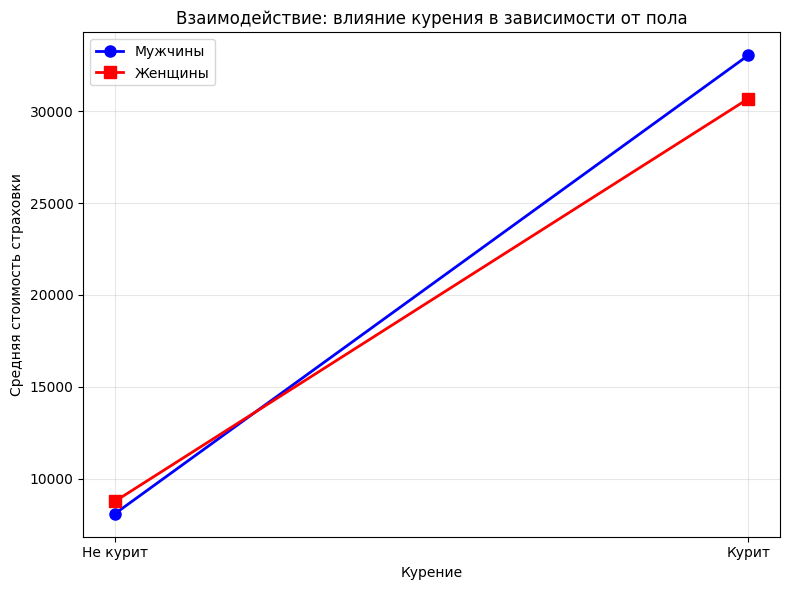

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

x = [0, 1]
male_means = [group_means[('no', 'male')], group_means[('yes', 'male')]]
female_means = [group_means[('no', 'female')], group_means[('yes', 'female')]]

ax.plot(x, male_means, '-o', label='Мужчины', linewidth=2, color='blue', markersize=8)
ax.plot(x, female_means, '-s', label='Женщины', linewidth=2, color='red', markersize=8)

ax.set_xlabel('Курение')
ax.set_ylabel('Средняя стоимость страховки')
ax.set_title('Взаимодействие: влияние курения в зависимости от пола')
ax.set_xticks(x)
ax.set_xticklabels(['Не курит', 'Курит'])
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()